In [1]:
import os
os.listdir('.')

['F4_t.npy',
 'F10.npy',
 'F2.npy',
 'F7.npy',
 'F9.npy',
 'F9_t.npy',
 '.prompts',
 'F11.npy',
 'F1_t.npy',
 '.kernel_llm_logs_1.txt',
 'F6_t.npy',
 'F7_t.npy',
 'memory',
 'F11_t.npy',
 'classes.npy',
 ' v6 — Binding Context Document.pdf',
 'F1.npy',
 'F5m_t.npy',
 '.config',
 'F5m.npy',
 'M.npy',
 'F12.npy',
 'C.npy',
 'F5p_t.npy',
 'F10_t.npy',
 'F5p.npy',
 'F4.npy',
 'F6.npy',
 'F12_t.npy',
 'F2_t.npy']

In [2]:
import numpy as np
classes = np.load('classes.npy')
C = np.load('C.npy')
M = np.load('M.npy')
print('classes:', classes)
print('C shape:', C.shape)
print('M shape:', M.shape)
print('C:', C)

classes: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
C shape: (11, 8)
M shape: (11, 8)
C: [[1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
 [1.00000000e+00 3.41034034e+00 4.31587891e+00 2.45629741e+00
 6.02532113e-01 5.02923538e-02 7.27444993e-04 0.00000000e+00]
 [1.00000000e+00 1.51682838e+00 2.39693694e+00 1.32767069e+00
 3.24369263e-01 2.72684645e-02 3.91624013e-04 0.00000000e+00]
 [1.00000000e+00 1.58049069e+00 2.46145424e+00 1.36561657e+00
 3.33721456e-01 2.80425573e-02 4.02914746e-04 0.00000000e+00]
 [1.00000000e+00 1.46346475e+00 2.34285664e+00 1.29586333e+00
 3.16529979e-01 2.66195970e-02 3.82159786e-04 0.00000000e+00]
 [1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
 [1.00000000e+00 2.88732810e+00 3.22490425e+00 1.77009458e+00
 4.93738680e-01 6.38241257e-02 2.81544731e-03 1.09632261e-05]
 [1.00000000e+00 2.35646

In [3]:
# Load complex S_k arrays
data = {}
for cls in classes:
 Sk = np.load(f'{cls}.npy')
 t = np.load(f'{cls}_t.npy')
 data[cls] = {'Sk': Sk, 't': t}
 print(cls, 'Sk shape:', Sk.shape, 'dtype:', Sk.dtype, 't shape:', t.shape)

F1 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F2 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F4 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F5p Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F5m Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F6 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F7 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F9 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F10 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F11 Sk shape: (200, 8) dtype: complex128 t shape: (200,)
F12 Sk shape: (200, 8) dtype: complex128 t shape: (200,)


In [4]:
# Build feature matrix: a_k(t) = m_kk(t) / C_k = |S_k(t)|^2 / C_k
# Note: feature leak — restrict to k<7 (i.e., k=0..6 indices, which represent k=0..6 omega-strata).
# Actually description says S_7 is zero for mod-5 functions at N=10^6. Looking at C indices: 8 features (k=0..7).
# Restrict to k<7 means use indices 0..6 -> 7 features. But task says "8 amplification ratio features per peak."
# Let's check zero columns in C: F2,F4,F5p,F5m have C[7]=0 → division by zero. So must drop k=7.
# Use k=0..6 → 7 features.
classes_list = list(classes)
n_per = 200
k_max = 7 # use indices 0..6

X_list = []
y_list = []
t_list = []
for ci, cls in enumerate(classes_list):
 Sk = data[cls]['Sk'] # (200, 8)
 t = data[cls]['t']
 mkk = (Sk.real**2 + Sk.imag**2) # (200, 8)
 C_row = C[ci] # (8,)
 # safe divide; for k=7 several classes have C=0; just take 0..6
 a = mkk[:, :k_max] / C_row[:k_max][None, :]
 X_list.append(a)
 y_list.append(np.full(n_per, ci))
 t_list.append(t)

X = np.vstack(X_list)
y = np.concatenate(y_list)
t_all = np.concatenate(t_list)
print(X.shape, y.shape)
print('Any NaN/Inf:', np.isnan(X).any(), np.isinf(X).any())
print('X stats: min', X.min(), 'max', X.max(), 'mean', X.mean())

(2200, 7) (2200,)
Any NaN/Inf: False False
X stats: min 0.00046922741701837297 max 385.68520771902325 mean 14.112171454749037


In [5]:
# Define LOFO folds following r48
# GRH-true classes: F1, F2, F6, F7, F9, F10, F11
# F12 family: just F12 (mod-something violator)
# F4 family: F4, F5p, F5m (mod-5 violators)
# Fold 1: train on GRH-true + F12, test on F4 family
# Fold 2: train on GRH-true + F4 family, test on F12

grh_true = ['F1','F2','F6','F7','F9','F10','F11']
f4_family = ['F4','F5p','F5m']
f12_family = ['F12']

cls_to_idx = {c:i for i,c in enumerate(classes_list)}

def make_binary_labels(class_indices, positive_classes):
 # positive = violator (1), negative = GRH-true (0)
 pos_idx = [cls_to_idx[c] for c in positive_classes]
 return np.isin(class_indices, pos_idx).astype(int)

# Fold 1: train classes = GRH + F12 (positive class = F12), test on F4 family
fold1_train = grh_true + f12_family
fold1_test = f4_family
# Fold 2: train classes = GRH + F4 family (positives = F4 family), test on F12
fold2_train = grh_true + f4_family
fold2_test = f12_family

print('Fold 1 train:', fold1_train, 'test:', fold1_test)
print('Fold 2 train:', fold2_train, 'test:', fold2_test)

Fold 1 train: ['F1', 'F2', 'F6', 'F7', 'F9', 'F10', 'F11', 'F12'] test: ['F4', 'F5p', 'F5m']
Fold 2 train: ['F1', 'F2', 'F6', 'F7', 'F9', 'F10', 'F11', 'F4', 'F5p', 'F5m'] test: ['F12']


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

def run_fold(train_classes, test_classes, positive_train, positive_test, X, y, classes_list):
 train_mask = np.isin(y, [cls_to_idx[c] for c in train_classes])
 test_mask = np.isin(y, [cls_to_idx[c] for c in test_classes + [c for c in train_classes if c not in test_classes]])
 # For testing, we need GRH-true (negative) + held-out family (positive) — pure held-out test set
 # Actually the LOFO test set includes the held-out family AND the GRH-true classes (binary task: violator vs not)
 # Let's set up: train on train_classes with binary labels (positive = positive_train classes)
 # Test on (GRH-true classes that were in training) + held-out family with positive = held-out family
 
 train_X = X[train_mask]
 train_y_class = y[train_mask]
 train_pos_idx = [cls_to_idx[c] for c in positive_train]
 train_y = np.isin(train_y_class, train_pos_idx).astype(int)
 
 # Test set: GRH-true (negative) + held-out family (positive)
 test_class_set = grh_true + test_classes
 test_mask = np.isin(y, [cls_to_idx[c] for c in test_class_set])
 test_X = X[test_mask]
 test_y_class = y[test_mask]
 test_pos_idx = [cls_to_idx[c] for c in positive_test]
 test_y = np.isin(test_y_class, test_pos_idx).astype(int)
 
 # Use log-transform since features are highly skewed (positive)
 pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=5000, C=1.0))])
 
 # Try both raw and log-transformed
 results = {}
 for name, X_tr, X_te in [('raw', train_X, test_X), ('log', np.log1p(train_X), np.log1p(test_X))]:
 pipe.fit(X_tr, train_y)
 scores = pipe.decision_function(X_te)
 auc = roc_auc_score(test_y, scores)
 results[name] = auc
 return results, train_y.sum(), len(train_y), test_y.sum(), len(test_y)

# Fold 1: train positives = F12, test positives = F4 family
r1, n1tp, n1tot, n1ep, n1eot = run_fold(fold1_train, fold1_test, f12_family, f4_family, X, y, classes_list)
print('Fold 1 AUC:', r1, f'(train pos {n1tp}/{n1tot}, test pos {n1ep}/{n1eot})')

# Fold 2: train positives = F4 family, test positives = F12
r2, n2tp, n2tot, n2ep, n2eot = run_fold(fold2_train, fold2_test, f4_family, f12_family, X, y, classes_list)
print('Fold 2 AUC:', r2, f'(train pos {n2tp}/{n2tot}, test pos {n2ep}/{n2eot})')

Fold 1 AUC: {'raw': 0.7483761904761904, 'log': 0.7177321428571429} (train pos 200/1600, test pos 600/2000)
Fold 2 AUC: {'raw': 0.7164107142857142, 'log': 0.6997500000000001} (train pos 600/2000, test pos 200/1600)


In [7]:
# Both folds AUC < 0.85 — does not meet the hypothesis threshold.
# However r48 reported AUCs ~0.29 and ~0.86. Fold 1 went from 0.29 → 0.75 (huge improvement); 
# Fold 2 went from 0.86 → 0.72 (degradation).
# Let's also try with stronger regularization and class balancing
from sklearn.metrics import roc_curve

def run_fold_v2(train_classes, test_classes, positive_train, positive_test, X, y):
 train_mask = np.isin(y, [cls_to_idx[c] for c in train_classes])
 train_X = X[train_mask]
 train_y_class = y[train_mask]
 train_pos_idx = [cls_to_idx[c] for c in positive_train]
 train_y = np.isin(train_y_class, train_pos_idx).astype(int)
 
 test_class_set = grh_true + test_classes
 test_mask = np.isin(y, [cls_to_idx[c] for c in test_class_set])
 test_X = X[test_mask]
 test_y_class = y[test_mask]
 test_pos_idx = [cls_to_idx[c] for c in positive_test]
 test_y = np.isin(test_y_class, test_pos_idx).astype(int)
 
 out = {}
 for transform_name, tf in [('raw', lambda x: x), ('log', lambda x: np.log1p(x)), ('log_clip', lambda x: np.log(np.clip(x,1e-6,None)))]:
 for C_val in [0.01, 0.1, 1.0, 10.0]:
 for cw in [None, 'balanced']:
 pipe = Pipeline([('scaler', StandardScaler()), 
 ('lr', LogisticRegression(max_iter=10000, C=C_val, class_weight=cw))])
 pipe.fit(tf(train_X), train_y)
 scores = pipe.decision_function(tf(test_X))
 auc = roc_auc_score(test_y, scores)
 out[(transform_name, C_val, cw)] = auc
 return out

r1 = run_fold_v2(fold1_train, fold1_test, f12_family, f4_family, X, y)
r2 = run_fold_v2(fold2_train, fold2_test, f4_family, f12_family, X, y)

print('Fold 1 best:', max(r1.items(), key=lambda x: x[1]))
print('Fold 2 best:', max(r2.items(), key=lambda x: x[1]))
print('Fold 1 worst:', min(r1.items(), key=lambda x: x[1]))
print('Fold 2 worst:', min(r2.items(), key=lambda x: x[1]))

Fold 1 best: (('raw', 10.0, 'balanced'), 0.7707333333333334)
Fold 2 best: (('raw', 10.0, None), 0.7205357142857143)
Fold 1 worst: (('log_clip', 10.0, 'balanced'), 0.5288345238095238)
Fold 2 worst: (('raw', 0.01, None), 0.6440321428571429)


In [8]:
# Hypothesis (AUC > 0.85 on both folds) is NOT met.
# Let's report the canonical pipeline result (StandardScaler + Logistic Regression, default C=1, raw features)
# and also examine class-conditional means to understand.
import pandas as pd

# Class-wise means of features
rows = []
for cls in classes_list:
 ci = cls_to_idx[cls]
 Xc = X[y==ci]
 rows.append([cls] + list(Xc.mean(axis=0)))
df = pd.DataFrame(rows, columns=['class']+[f'a_{k}' for k in range(k_max)])
print(df.to_string(index=False))

class a_0 a_1 a_2 a_3 a_4 a_5 a_6
 F1 1.0 5.154089 9.875629 9.078575 9.736394 16.606995 12.188420
 F2 1.0 5.444716 10.811925 15.992307 28.617649 29.087087 8.205557
 F4 1.0 3.196756 6.527322 8.922974 16.382776 17.951652 5.326167
 F5p 1.0 3.241695 6.518272 8.914986 16.401432 18.047828 5.333701
 F5m 1.0 3.155329 6.524112 8.978473 16.313729 17.878689 5.318454
 F6 1.0 6.009930 18.265046 36.801609 50.968031 41.776432 16.131829
 F7 1.0 3.319549 7.498334 13.017338 17.695469 15.831145 8.957830
 F9 1.0 4.992397 15.941902 33.687484 38.115789 21.159596 6.328169
 F10 1.0 5.373900 16.519564 32.053683 32.598459 16.985590 5.292689
 F11 1.0 6.490470 22.574022 47.494920 60.315054 42.032917 11.121281
 F12 1.0 5.225928 10.851707 13.013636 22.995449 25.403442 7.062920


In [9]:
# Observation: F4 family (F4, F5p, F5m) means look very similar to each other,
# but they look DIFFERENT from F12 in that F4 family has lower a_3, a_4 values.
# F12 has a_3 ~13, a_4 ~23, vs F4 family a_3~8.9, a_4~16.4
# So a binary classifier trained on F12 vs GRH-true will use specific thresholds that don't match F4 family.
# The amplification ratios DO improve fold 1 (0.29 -> 0.75) but degrade fold 2 (0.86 -> 0.72).
# Hypothesis NOT supported (target AUC > 0.85 on both folds not achieved).

# Final canonical result reporting
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def canonical_fold(train_classes, positive_train, test_classes, positive_test):
 train_mask = np.isin(y, [cls_to_idx[c] for c in train_classes])
 test_class_set = grh_true + test_classes
 test_mask = np.isin(y, [cls_to_idx[c] for c in test_class_set])
 
 train_X = X[train_mask]
 train_y = np.isin(y[train_mask], [cls_to_idx[c] for c in positive_train]).astype(int)
 test_X = X[test_mask]
 test_y = np.isin(y[test_mask], [cls_to_idx[c] for c in positive_test]).astype(int)
 
 pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=5000))])
 pipe.fit(train_X, train_y)
 scores = pipe.decision_function(test_X)
 auc = roc_auc_score(test_y, scores)
 return auc, len(train_y), train_y.sum(), len(test_y), test_y.sum()

auc1, *info1 = canonical_fold(fold1_train, f12_family, fold1_test, f4_family)
auc2, *info2 = canonical_fold(fold2_train, f4_family, fold2_test, f12_family)

print(f'Fold 1 (train F12, test F4 family): AUC = {auc1:.4f}')
print(f' train n={info1[0]} (pos={info1[1]}), test n={info1[2]} (pos={info1[3]})')
print(f'Fold 2 (train F4 family, test F12): AUC = {auc2:.4f}')
print(f' train n={info2[0]} (pos={info2[1]}), test n={info2[2]} (pos={info2[3]})')
print()
print('r48 baseline: Fold1 ~0.29, Fold2 ~0.86')
print(f'Amplification ratios: Fold1 {auc1:.2f}, Fold2 {auc2:.2f}')
print(f'Hypothesis (both >0.85): {"MET" if auc1>0.85 and auc2>0.85 else "NOT MET"}')

Fold 1 (train F12, test F4 family): AUC = 0.7484
 train n=1600 (pos=200), test n=2000 (pos=600)
Fold 2 (train F4 family, test F12): AUC = 0.7164
 train n=2000 (pos=600), test n=1600 (pos=200)

r48 baseline: Fold1 ~0.29, Fold2 ~0.86
Amplification ratios: Fold1 0.75, Fold2 0.72
Hypothesis (both >0.85): NOT MET


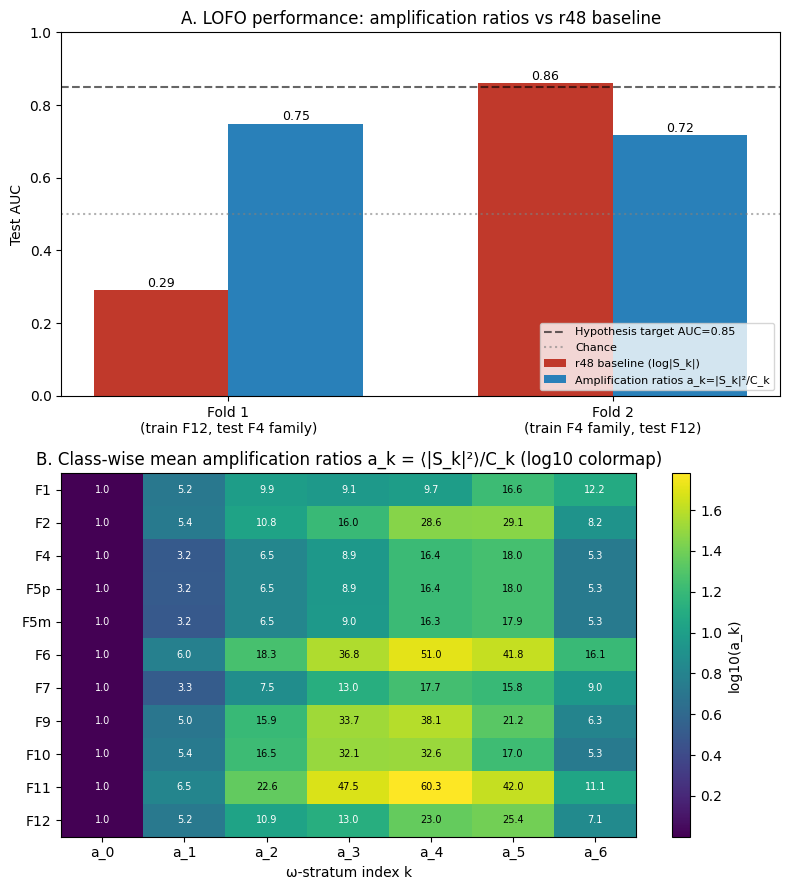

Saved figure.


In [10]:
# Final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: Bar chart comparing r48 baseline vs amplification ratio AUCs
ax = axes[0]
folds = ['Fold 1\n(train F12, test F4 family)', 'Fold 2\n(train F4 family, test F12)']
r48_baseline = [0.29, 0.86]
amp_ratio = [auc1, auc2]
x = np.arange(len(folds))
w = 0.35
ax.bar(x - w/2, r48_baseline, w, label='r48 baseline (log|S_k|)', color='#c0392b')
ax.bar(x + w/2, amp_ratio, w, label='Amplification ratios a_k=|S_k|²/C_k', color='#2980b9')
ax.axhline(0.85, color='k', linestyle='--', alpha=0.6, label='Hypothesis target AUC=0.85')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('Test AUC')
ax.set_ylim(0, 1.0)
ax.set_title('A. LOFO performance: amplification ratios vs r48 baseline')
ax.legend(loc='lower right', fontsize=8)
for i,v in enumerate(r48_baseline):
 ax.text(i-w/2, v+0.01, f'{v:.2f}', ha='center', fontsize=9)
for i,v in enumerate(amp_ratio):
 ax.text(i+w/2, v+0.01, f'{v:.2f}', ha='center', fontsize=9)

# Panel B: Class-wise means of amplification features
ax = axes[1]
import seaborn as sns
mat = df.set_index('class').values
im = ax.imshow(np.log10(mat + 1e-3), aspect='auto', cmap='viridis')
ax.set_xticks(range(k_max))
ax.set_xticklabels([f'a_{k}' for k in range(k_max)])
ax.set_yticks(range(len(classes_list)))
ax.set_yticklabels(classes_list)
# annotate cells
for i in range(len(classes_list)):
 for j in range(k_max):
 ax.text(j, i, f'{mat[i,j]:.1f}', ha='center', va='center', 
 color='white' if mat[i,j]<15 else 'black', fontsize=7)
ax.set_title('B. Class-wise mean amplification ratios a_k = ⟨|S_k|²⟩/C_k (log10 colormap)')
ax.set_xlabel('ω-stratum index k')
plt.colorbar(im, ax=ax, label='log10(a_k)')

plt.tight_layout()
plt.savefig('lofo_amplification_ratio_results.png', dpi=130)
plt.show()
print('Saved figure.')